<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana15/Energia_vs_tiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

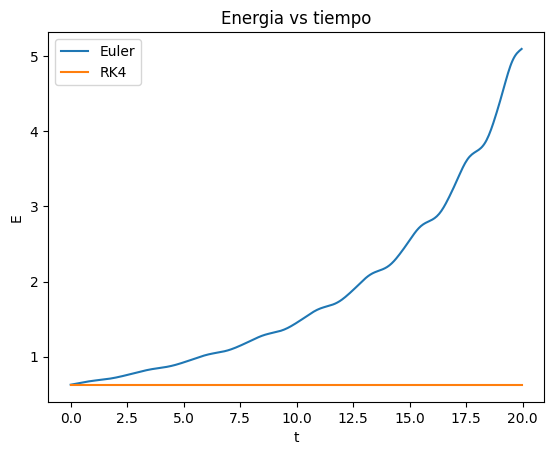

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def f(x, v, alpha):
    return v, -x - alpha*x**3

def energia(x, v, alpha):
    return 0.5*v**2 + 0.5*x**2 + 0.25*alpha*x**4

alpha = 0.5
dt = 0.05
N = 400

x_e, v_e = 1.0, 0.0
x_rk, v_rk = 1.0, 0.0

E_e_list, E_rk_list, t_list = [], [], []

for i in range(N):
    t = i*dt

    # Euler
    dx, dv = f(x_e, v_e, alpha)
    x_e += dt*dx
    v_e += dt*dv

    # RK4
    k1x, k1v = f(x_rk, v_rk, alpha)
    k2x, k2v = f(x_rk + 0.5*dt*k1x, v_rk + 0.5*dt*k1v, alpha)
    k3x, k3v = f(x_rk + 0.5*dt*k2x, v_rk + 0.5*dt*k2v, alpha)
    k4x, k4v = f(x_rk + dt*k3x, v_rk + dt*k3v, alpha)

    x_rk += (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
    v_rk += (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)

    E_e_list.append(energia(x_e, v_e, alpha))
    E_rk_list.append(energia(x_rk, v_rk, alpha))
    t_list.append(t)

plt.plot(t_list, E_e_list, label="Euler")
plt.plot(t_list, E_rk_list, label="RK4")

plt.xlabel("t")
plt.ylabel("E")
plt.title("Energia vs tiempo")
plt.legend()

plt.savefig("Energia_vs_tiempo.pdf")
plt.show()

files.download("Energia_vs_tiempo.pdf")